# Simulating TASEP Models
___

In [1]:
import sys; from pathlib import Path; current_dir = Path().resolve()
src_dir = next(parent / 'src' for parent in Path().absolute().parents if (parent / 'src').is_dir())
sys.path.insert(0, str(src_dir))
main_dir = Path(src_dir.parents[0])
from imports import * 

In [2]:
# set the random seed for reproducibility
np.random.seed(42)

## Loading and plotting the file sequences.
___

In [ ]:
# Modeling
from tasep_models import *
tag_file = 'UTAG'
if tag_file == 'SUN':
    tag_sequence = tag_dict['SUN']
    dna_file_path = main_dir / 'gene_sequences' / 'utag_project' / 'pNZ266(pUB-24xGCN4-KDM5B-MS2).dna'
elif tag_file == 'UTAG':
    tag_sequence = tag_dict['U']
    dna_file_path = main_dir / 'gene_sequences' / 'utag_project' / 'pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna'
elif tag_file == 'ALFA':
    tag_sequence = tag_dict['ALFA']
    dna_file_path = main_dir / 'gene_sequences' / 'utag_project' / 'pNZ267(pUB-24xALFAtag-KDM5B-MS2).dna'

dna_file_path.name.split('.')[0]
plasmid_name = dna_file_path.name.split('.')[0].replace('(','_').replace(')','_')
plasmid_name

# Creating a results folder for outputs
results_folder = current_dir.joinpath('results_simulations') 
results_folder.mkdir(exist_ok=True)

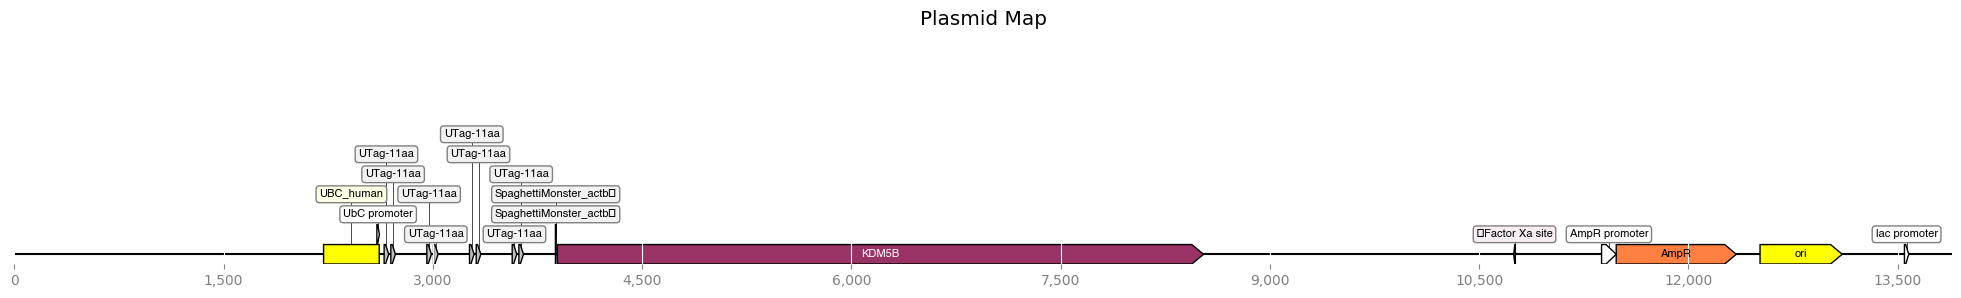

In [4]:
# reading the sequence and extracting the elongation rates
protein, rna, dna, indexes_tags, seq_record, graphic_features  = read_sequence(seq=dna_file_path, min_protein_length=50,TAG=[tag_sequence])
plasmid_figure = plot_plasmid(seq_record, graphic_features,figure_width=25, figure_height=3)

gene_length = len(protein)+1 # adding 1 to account for the stop codon
tag_positions_first_probe_vector = indexes_tags[0]
tag_positions_second_probe_vector = indexes_tags[1] if len(indexes_tags) > 1 else None

first_probe_position_vector = create_probe_vector(tag_positions_first_probe_vector, gene_length)
second_probe_position_vector = create_probe_vector(tag_positions_second_probe_vector, gene_length) if tag_positions_second_probe_vector is not None else None


## Simulation parameters 

___

In [5]:
# # Initial conditions
ki = 0.031 # Initiation rate
global_elongation_rate = 3.1  # Elongation rates for positions 1 to N-1
number_repetitions = 300
burnin_time = 2500
t_max = 360*10 #timePerturbationApplication + 25*60  # Maximum time
step_size_in_sec = 5 # 5
time_array = np.arange(0, t_max, step_size_in_sec)
number_tested_parameters = 5
downsample = False
downsample_factor = 3
MAD_THRESHOLD_FACTOR = 4
multi_tau = False

In [6]:
ke = calculate_codon_elongation_rates (rna, global_elongation_rate=global_elongation_rate)

In [7]:
intensity_vector_first_signal_ode,intensity_vector_second_signal_ode = simulate_TASEP_ODE(ki, ke, gene_length, t_max,first_probe_position_vector,second_probe_position_vector,burnin_time, time_interval_in_seconds= step_size_in_sec)

In [8]:
constant_elongation_rate = None # this is a signal to the SSA to use the elongation rates considering sequence variability.
list_ribosome_trajectories,list_occupancy_output, matrix_intensity_first_signal_RT, matrix_intensity_second_signal_RT = simulate_TASEP_SSA(ki, ke, gene_length, t_max,
                                time_interval_in_seconds=step_size_in_sec,
                                number_repetitions=number_repetitions, 
                                first_probe_position_vector=first_probe_position_vector, 
                                second_probe_position_vector=second_probe_position_vector,
                                burnin_time=burnin_time,
                                constant_elongation_rate=constant_elongation_rate,
                                fast_output=False)
                         

In [9]:

# calculating the mean occupancy across all frames
ribosomal_density = np.round( (gene_length/global_elongation_rate) *ki , 1)
print(f'Ribosomal density: {ribosomal_density} ribosomes per gene length ({gene_length} codons)')
ribosomal_footprint = 10
# ribosomal density covering the RNA length
ribosomal_density_coverage = np.round( (ribosomal_density * ribosomal_footprint) / gene_length, 2)
percentage_coverage = (ribosomal_density_coverage * 100)  # percentage coverage of the gene length by ribosomes
print(f'Ribosomal density coverage: {np.round(ribosomal_density_coverage,2)} ribosomes per gene length ({gene_length} codons, {percentage_coverage:.2f}% coverage)')
len(list_occupancy_output)
# each element in the list in list_occupancy_output is an array with shape [gene_location, frame]. Calculate the number of non-zero elements in each column, and then take the mean across the frames.
occupancy_array = np.array([np.mean(np.count_nonzero(occupancy, axis=0)) for occupancy in list_occupancy_output])
# print validated ribosomal density with simulated data
print(f'Ribosomal density with simulated data: { np.round( np.mean(occupancy_array), 2)} ribosomes per gene length ({gene_length} codons)')


Ribosomal density: 19.7 ribosomes per gene length (1968 codons)
Ribosomal density coverage: 0.1 ribosomes per gene length (1968 codons, 10.00% coverage)
Ribosomal density with simulated data: 19.36 ribosomes per gene length (1968 codons)


In [10]:
(gene_length * ki) /global_elongation_rate

19.68

In [11]:
((20*10) / 1970 )*100

10.152284263959391

In [12]:
list_occupancy_output[0].shape

(1969, 720)

In [13]:
# calculate the mean and std of the matrix_intensity_first_signal_RT and matrix_intensity_second_signal_RT
mean_first_signal_RT = np.mean(matrix_intensity_first_signal_RT, axis=0)
sem_first_signal_RT = np.std(matrix_intensity_first_signal_RT, axis=0)/np.sqrt(number_repetitions)
if second_probe_position_vector is not None:
    mean_second_signal_RT = np.mean(matrix_intensity_second_signal_RT, axis=0)
    sem_second_signal_RT = np.std(matrix_intensity_second_signal_RT, axis=0)/np.sqrt(number_repetitions)

In [14]:
def plot_trajectories(matrix_intensity_first_signal_RT, intensity_vector_first_signal_ode, time_array, number_repetitions, plot_color = 'orangered'):
    # --- Set fonts and background as before ---
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    plt.rcParams["axes.edgecolor"] = "black"
    plt.rcParams["axes.labelcolor"] = "black"
    plt.rcParams["xtick.color"] = "black"
    plt.rcParams["ytick.color"] = "black"
    # --- Determine the global intensity range from both datasets ---
    global_min = min(matrix_intensity_first_signal_RT.min(), intensity_vector_first_signal_ode.min())
    global_max = max(matrix_intensity_first_signal_RT.max(), intensity_vector_first_signal_ode.max())
    # --- Create subplots: left for trajectories, right for histogram ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3), gridspec_kw={'width_ratios': [4, 1]})
    # --- Left Plot: Trajectories ---
    for i in range(number_repetitions):
        if i == 0:
            ax1.plot(time_array, matrix_intensity_first_signal_RT[i, :],
                    label='SSA', color=plot_color, alpha=1, linewidth=2)
        else:
            ax1.plot(time_array, matrix_intensity_first_signal_RT[i, :],
                    color=plot_color, alpha=0.1, linewidth=0.4)
    ax1.plot(time_array, intensity_vector_first_signal_ode, label='ODE', color='k', linewidth=3)
    ax1.set_xlabel('Time (s)', fontsize=20)
    ax1.set_ylabel('Intensity (a.u.)', fontsize=20)
    ax1.set_ylim(global_min, global_max)
    # Set the axes frame with a distinct black border for ax1:
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    # Place the legend in the upper right corner with a black border
    legend1 = ax1.legend(loc='upper right', fontsize=14)
    legend1.get_frame().set_edgecolor('black')
    legend1.get_frame().set_linewidth(1.5)
    ax1.grid(False)  # Remove grid lines
    ax1.tick_params(axis='both', which='major', labelsize=16)
    # --- Right Plot: Horizontal Histogram of SSA Trajectories ---
    # Flatten all SSA trajectory values into a single array
    ssa_values = matrix_intensity_first_signal_RT.flatten()
    ax2.hist(ssa_values, bins=100, orientation='horizontal',
            color=plot_color, alpha=0.7)
    ax2.set_xlabel('Counts', fontsize=20)
    ax2.set_ylabel('Intensity (a.u.)', fontsize=20)
    ax2.set_ylim(global_min, global_max)
    # set axis font size
    ax2.tick_params(axis='both', which='major', labelsize=16)
    # Set the axes frame with a distinct black border for ax2:
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    ax2.grid(False)  # Remove grid lines
    plt.tight_layout()
# save as png and svg in results_folder
    plt.savefig(results_folder.joinpath('TASEP_SSA.png'), dpi=300, bbox_inches='tight')
    plt.savefig(results_folder.joinpath('TASEP_SSA.svg'), bbox_inches='tight')

    plt.show()

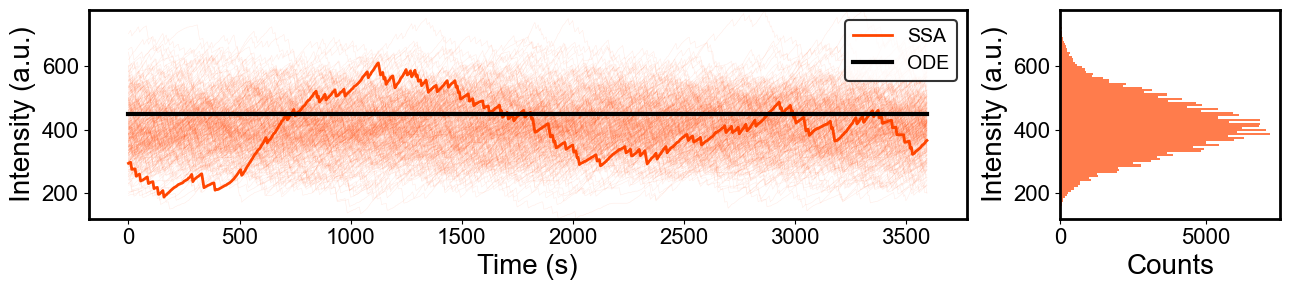

In [15]:
plot_trajectories(matrix_intensity_first_signal_RT, intensity_vector_first_signal_ode, time_array, number_repetitions,plot_color='orangered')

In [16]:
selected_trajectory = 0

ribosome_trajectories = list_ribosome_trajectories[selected_trajectory]    
ribosome_trajectories = ribosome_trajectories[:,:]
intensity_vector_first_signal = matrix_intensity_first_signal_RT[selected_trajectory,:]
if second_probe_position_vector is not None:
    intensity_vector_second_signal = matrix_intensity_second_signal_RT[selected_trajectory,:]
else:
    intensity_vector_second_signal = None

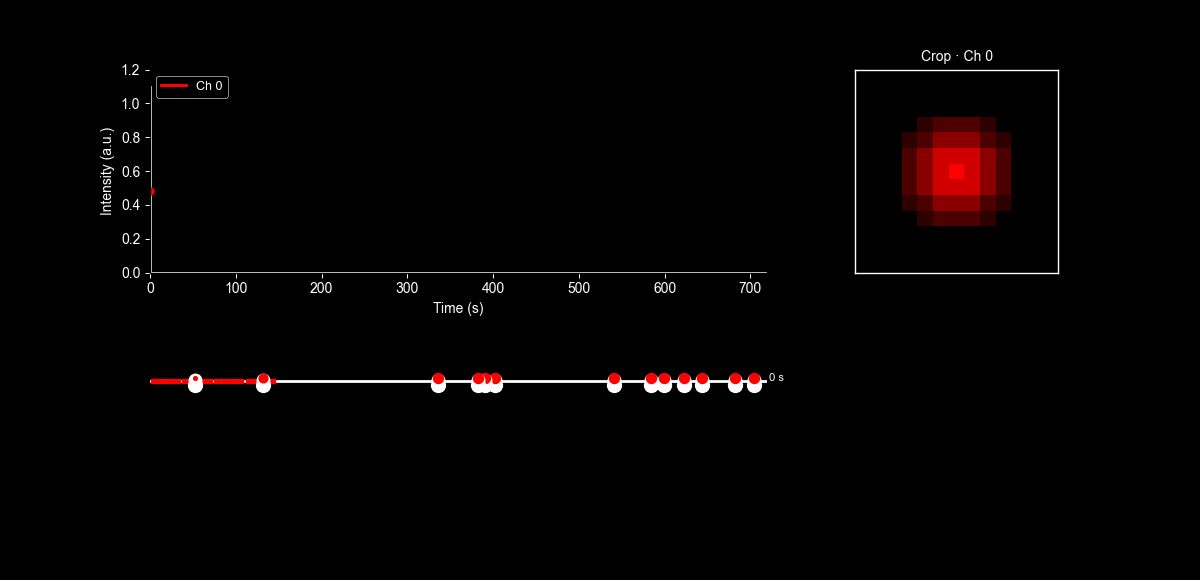

In [17]:
str_ki = str(ki).replace('.','_')
str_k = str(global_elongation_rate).replace('.','_')
fileNameGif = 'simulation_'+plasmid_name+'_ke_'+str_k+'_ki_'+str_ki 
plot_RibosomeMovement_and_Microscope(ribosome_trajectories, intensity_vector_first_signal, tag_positions_first_probe_vector, SecondIntensityVector=intensity_vector_second_signal, second_probePositions=tag_positions_second_probe_vector,FrameVelocity=10,fileNameGif=fileNameGif)

In [18]:
# simulating missing data 
simulate_missing_data = False
if simulate_missing_data:
    array_simulated,_ = mi.Utilities().simulate_missing_data(matrix_intensity_first_signal_RT,matrix2= None, percentage_to_remove_data=5,replace_with='nan')
    array_simulated  = mi.Utilities().shift_trajectories(array_simulated, )
else:
    array_simulated = matrix_intensity_first_signal_RT

In [19]:

def print_parameters (gene_length, tag_positions_first_probe_vector, g_0, dwell_time):
    print ('------------------------------------')
    ke_calculated_ch0 =  np.round( gene_length /dwell_time , 2)
    ke_calculated_ch0_corrected =  np.round( (gene_length-(np.max(tag_positions_first_probe_vector))) /dwell_time  , 2)
    print ('------------------------------------')
    print('Elongation rates: ')
    print('Calculated ch0', ke_calculated_ch0 , ' Corrected: ',ke_calculated_ch0_corrected, )
    print ('------------------------------------')
    print('Initiation rates: ')
    ki_calculated = np.round( 1/ (g_0* dwell_time), 3)
    print('Calculated', ki_calculated, ' 1/sec')
    print ('------------------------------------')
    print('Ribosomal density: ')
    ribosomal_density = np.round( (gene_length/ke_calculated_ch0_corrected) *ki_calculated , 1)
    print('Calculated', np.round(ribosomal_density,1) , ' average number of ribosomes per RNA')
    print ('------------------------------------')
    print('Ribosomal occurrence: ')
    ribsomal_space = 1/ki_calculated 
    print('Calculated', np.round(ribsomal_space,2) , ' seconds between ribosome initiation')
    print ('------------------------------------')
    return None

print_parameters(gene_length, tag_positions_first_probe_vector, g_0=0.08, dwell_time=279)

------------------------------------
------------------------------------
Elongation rates: 
Calculated ch0 7.05  Corrected:  5.64
------------------------------------
Initiation rates: 
Calculated 0.045  1/sec
------------------------------------
Ribosomal density: 
Calculated 15.7  average number of ribosomes per RNA
------------------------------------
Ribosomal occurrence: 
Calculated 22.22  seconds between ribosome initiation
------------------------------------


## Testing the temporal resolution
___

In [20]:
list_ke = np.linspace(2,10,number_tested_parameters).astype(int)

In [21]:
list_mean_correlation = []
list_std_correlation = []
list_lags = []
for i, ke_constant in enumerate (list_ke):
    ke = calculate_codon_elongation_rates (rna, global_elongation_rate=ke_constant)
    ssa_array = simulate_TASEP_SSA(ki, ke, gene_length, t_max,
                                time_interval_in_seconds=step_size_in_sec,
                                number_repetitions=number_repetitions, 
                                first_probe_position_vector=first_probe_position_vector, 
                                second_probe_position_vector=second_probe_position_vector,
                                burnin_time=burnin_time,
                                constant_elongation_rate=ke_constant,
                                fast_output=True)[2]
    # Calculating the autocorrelation of the intensity signal
    mean_correlation, std_correlation, lags, correlations_array, dwell_time = mi.Correlation(primary_data=ssa_array,
                                                                                            max_lag=None, 
                                                                                            nan_handling='forward_fill',  #forward_fill, 'ignore'
                                                                                            shift_data=True,
                                                                                            return_full=False,
                                                                                            time_interval_between_frames_in_seconds=step_size_in_sec,
                                                                                            use_bootstrap=True,
                                                                                            show_plot=False,
                                                                                            start_lag=0,
                                                                                            fit_type='linear',
                                                                                            de_correlation_threshold=0.01,
                                                                                            correct_baseline=True,
                                                                                            use_linear_projection_for_lag_0=True,
                                                                                            save_plots=False,
                                                                                            use_global_mean= False,
                                                                                            remove_outliers = True,
                                                                                            MAD_THRESHOLD_FACTOR = MAD_THRESHOLD_FACTOR,
                                                                                            plot_individual_trajectories = False,
                                                                                            y_axes_min_max_list_values = None, #y_axes_min_max_list_values,
                                                                                            x_axes_min_max_list_values=None,
                                                                                            multi_tau=multi_tau,
                                                                                            plot_title=None).run()
    
    if downsample:
        mean_correlation = mean_correlation[::downsample_factor]
        std_correlation = std_correlation[::downsample_factor]
        lags = lags[::downsample_factor]

    list_mean_correlation.append(mean_correlation)
    list_std_correlation.append(std_correlation)
    list_lags.append(lags)


In [22]:
# calculate the min_max normalization to list_mean_correlation
list_mean_correlation_normalized = list_mean_correlation.copy()
for i, correlation in enumerate(list_mean_correlation):
    list_mean_correlation_normalized[i] = (correlation - np.nanmin(correlation))/(np.nanmax(correlation) - np.nanmin(correlation))

In [23]:
# calculate the theoretical deocorrelation values for each elongation rate.
list_theoretical_decorrelation = []
for i, ke_constant in enumerate (list_ke):
    list_theoretical_decorrelation.append( gene_length/ke_constant )
print(list_theoretical_decorrelation)

[984.0, 492.0, 328.0, 246.0, 196.8]


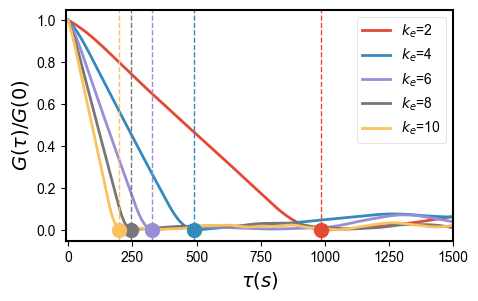

In [24]:
fig, ax = plt.subplots(figsize=(5, 3))
plt.rcParams.update({
    'figure.facecolor': 'white',    # figure background is white
    'axes.facecolor': 'white',      # axes (plot area) background is white
    'axes.edgecolor': 'black',      # axis spines (box) will be black
    'axes.linewidth': 1.5,          # thicker border lines for a clear box
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 14,           # axis labels: minimum 12
    'axes.titlesize': 14,           # title font size: 16
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
})
for i, mean_correlation in enumerate(list_mean_correlation_normalized):
    ax.plot(lags, mean_correlation, label='$k_e$='+str(list_ke[i]), linewidth=2)
    ax.fill_between(lags, mean_correlation - list_std_correlation[i], mean_correlation + list_std_correlation[i], alpha=0.2)
ax.set_xlabel(r'$\tau (s)$', fontsize=14)
ax.set_ylabel(r'$G(\tau)/G(0)$', fontdict={'fontsize': 14})
ax.legend()
# plot the line of the theoretical decorrelation as a vertical dashed line of the same color as the plot line. 
for i, theoretical_decorrelation in enumerate(list_theoretical_decorrelation):
    ax.axvline(x=theoretical_decorrelation, color=ax.get_lines()[i].get_color(), linestyle='--',lw=1)
# plot a circle at the theoretical decorrelation value and y =0
for i, theoretical_decorrelation in enumerate(list_theoretical_decorrelation):
    ax.plot(theoretical_decorrelation, 0, markersize=10, marker='o', color=ax.get_lines()[i].get_color())
ax.set_xlim([-10, 1500])
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# save as png and svg in results_folder
plt.savefig(results_folder.joinpath('SSA_correlation_ke.png'), dpi=300, bbox_inches='tight')
plt.savefig(results_folder.joinpath('SSA_correlation_ke.svg'), bbox_inches='tight')

plt.show()

### Testing initiation
____

In [25]:
list_ki = np.round(np.linspace(0.01,0.1,number_tested_parameters),2)
print(list_ki)

[0.01 0.03 0.06 0.08 0.1 ]


In [26]:
list_mean_correlation_ki = []
list_std_correlation_ki = []
list_lags_ki = []
fixed_ke = global_elongation_rate #5
for i, ki_tested in enumerate (list_ki):
    ke = calculate_codon_elongation_rates (rna, global_elongation_rate=fixed_ke)
    ssa_array = simulate_TASEP_SSA(ki_tested, ke, gene_length, t_max,
                                time_interval_in_seconds=step_size_in_sec,
                                number_repetitions=number_repetitions, 
                                first_probe_position_vector=first_probe_position_vector, 
                                second_probe_position_vector=second_probe_position_vector,
                                burnin_time=burnin_time,
                                constant_elongation_rate=fixed_ke,
                                fast_output=True)[2]
    # Calculating the autocorrelation of the intensity signal
    mean_correlation, std_correlation, lags, correlations_array, dwell_time = mi.Correlation(primary_data=ssa_array,
                                                                                            max_lag=None, 
                                                                                            nan_handling='forward_fill',  #forward_fill, 'ignore'
                                                                                            shift_data=True,
                                                                                            return_full=False,
                                                                                            time_interval_between_frames_in_seconds=step_size_in_sec,
                                                                                            use_bootstrap=True,
                                                                                            show_plot=False,
                                                                                            start_lag=0,
                                                                                            fit_type='linear',
                                                                                            de_correlation_threshold=0.01,
                                                                                            correct_baseline=True,
                                                                                            use_linear_projection_for_lag_0=True,
                                                                                            save_plots=False,
                                                                                            use_global_mean= True,
                                                                                            remove_outliers = True,
                                                                                            MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
                                                                                            plot_individual_trajectories = False,
                                                                                            y_axes_min_max_list_values = None, #y_axes_min_max_list_values,
                                                                                            x_axes_min_max_list_values=None,
                                                                                            multi_tau=multi_tau,
                                                                                            plot_title=None).run()
    if downsample:
        mean_correlation = mean_correlation[::downsample_factor]
        std_correlation = std_correlation[::downsample_factor]
        lags = lags[::downsample_factor]
    list_mean_correlation_ki.append(mean_correlation)
    list_std_correlation_ki.append(std_correlation)
    list_lags_ki.append(lags)


In [27]:
# calculate the theoretical G(0) values for each initiation rate.
theoretical_decorrelation_fixed_ke = gene_length/fixed_ke
list_theoretical_G0 = []
for i, ki_tested in enumerate (list_ki):
    list_theoretical_G0.append( 1/(ki_tested*theoretical_decorrelation_fixed_ke))

In [28]:
list_theoretical_G0

[0.15752032520325202,
 0.05250677506775067,
 0.026253387533875336,
 0.019690040650406502,
 0.015752032520325202]

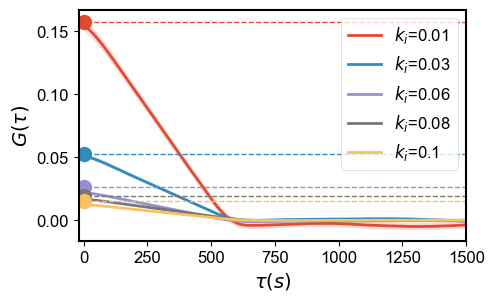

In [29]:
fig, ax = plt.subplots(figsize=(5, 3))
# Update rcParams to set a white background and Arial fonts.
plt.rcParams.update({
    'figure.facecolor': 'white',    # figure background is white
    'axes.facecolor': 'white',      # axes (plot area) background is white
    'axes.edgecolor': 'black',      # axis spines (box) will be black
    'axes.linewidth': 1.5,          # thicker border lines for a clear box
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 14,           # axis labels: minimum 12
    'axes.titlesize': 14,           # title font size: 16
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    # make ticks adn axels labels black fonts
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
})
for i, mean_correlation in enumerate(list_mean_correlation_ki):
    ax.plot(lags, mean_correlation, label='$k_i$='+str(np.round(list_ki[i],2)), linewidth=2)
    ax.fill_between(lags, mean_correlation - list_std_correlation_ki[i], mean_correlation + list_std_correlation_ki[i], alpha=0.2)
ax.set_xlabel(r'$\tau (s)$', fontsize=14)

ax.set_ylabel(r'$G(\tau)$', fontsize=14)
# legend location top right
ax.legend(loc='upper right', fontsize=12)

# plot the line of the theoretical decorrelation as a horizontal dashed line of the same color as the plot line.
for i, theoretical_G0 in enumerate(list_theoretical_G0):
    ax.axhline(y=theoretical_G0, color=ax.get_lines()[i].get_color(), linestyle='--',lw=1)
# plot a circle at the theoretical decorrelation value and x =0
for i, theoretical_G0 in enumerate(list_theoretical_G0):
    ax.plot(0, theoretical_G0, markersize=10, marker='o', color=ax.get_lines()[i].get_color())

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
ax.set_xlim([-20, 1500])

# save as png and svg in results_folder
plt.savefig(results_folder.joinpath('SSA_correlation_ki.png'), dpi=300, bbox_inches='tight')
plt.savefig(results_folder.joinpath('SSA_correlation_ki.svg'), bbox_inches='tight')
plt.show()
